In [1]:
# ! pip install -U torchvision
# !pip install -U torch

In [2]:
# 1: Bib
import pandas as pd
import numpy as np
from tqdm import tqdm 

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import resnet18

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


In [3]:
# 2: CSV laden

df = pd.read_csv("dataset/norm_labels.csv")

df.head()

# check:
print(df.shape)

(347085, 4)


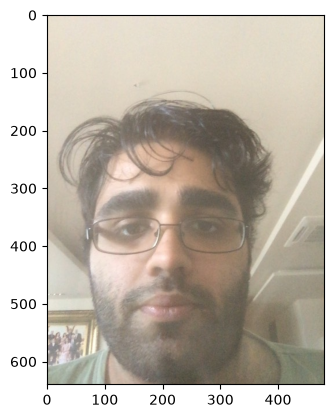

0.5 0.5


In [4]:
# 3: check a image

row = df.iloc[0]

img = Image.open(row["image_name"])

plt.imshow(img)
plt.show()

print(row["x"], row["y"])

In [5]:
# 4: Dataset Class: transfer CSV in PyTorch.

class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None, dataset_size=None,read_all4once=True):

        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.dataset_size=dataset_size if dataset_size is not None else len(self.df)
        self.read_all4once = read_all4once

        if self.read_all4once:
            img = Image.new("RGB", (500, 300))  # any size
            out = transform(img)
            self.images= torch.zeros([self.dataset_size]+list(out.shape))
            self.targets=torch.zeros(self.dataset_size,2)

        for idx in tqdm(range(self.dataset_size)):

            row = self.df.iloc[idx]

            image = Image.open(
                row["image_name"]
            ).convert("RGB")

            self.targets[idx] = torch.tensor(
                [row["x"], row["y"]],
                dtype=torch.float32
            )

            if self.transform:
                self.images[idx] = self.transform(image)
            else:
                self.images[idx]=image

    def __len__(self):

        return self.dataset_size
    

    def __getitem__(self, idx):

        return self.images[idx], self.targets[idx]


In [6]:
# 5: DataLoader

# Transformationen:

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


# Dataset:

train_dataset = GazeDataset(
    "./splits/norm_subject_train.csv",
    transform,dataset_size=2000,
)

test_dataset = GazeDataset(
    "./splits/norm_subject_test.csv",
    transform,dataset_size=500,
)

print(len(train_dataset))
print(len(test_dataset))


# Loader:

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)


100%|██████████| 500/500 [00:09<00:00, 51.63it/s]

2000
500


In [7]:
# 6: ResNet18 (Pretrainiertes Modell):

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# Load:

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)

model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),

    nn.Linear(
        512,
        128
    ),
    nn.ReLU(),

    nn.Dropout(0.2),

    nn.Linear(
        128,
        2
    )
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\rafei/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.44MB/s]


In [8]:
# 7: GPU

# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

model.to(device)

cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [9]:
# 8: Loss and Optimizer

# for regression:
# criterion = nn.MSELoss()

# for param in model.parameters():
#     param.requires_grad = False

# # Unfreeze the head
# for param in model.fc.parameters():
#     param.requires_grad = True


criterion = nn.SmoothL1Loss()

# Optimizer:
optimizer = torch.optim.Adam(
    model.parameters(),
    # model.fc.parameters(),
    lr=1e-4
)


In [10]:
def diagonal_errors(model, loader, device):
    model.eval()

    errors = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            preds = model(images)

            # Euclidean distance per sample
            dist = torch.sqrt(((preds - targets) ** 2).sum(dim=1))

            # normalize by image diagonal
            dist = dist / np.sqrt(2)

            errors.append(dist)

    errors = torch.cat(errors)

    return errors.mean().item(), errors.max().item()

In [ ]:
# 9: Training

from datetime import datetime

from tqdm import tqdm

epochs = 10
# epochs = 2
# epochs = 10
test_err_mean, test_err_max = None, None

for epoch in range(epochs):

    model.train()

    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}"
    )

    for images, targets in loop:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    
    train_mean_err, train_max_err = diagonal_errors(model, train_loader, device)
    test_mean_err, test_max_err = diagonal_errors(model, test_loader, device)

    if test_err_mean and test_err_max:
        if test_max_err < test_err_max:
            test_err_max = test_max_err
            torch.save(model.state_dict(),"best_model.pth")
    else:
        test_err_max = test_max_err
        torch.save(model.state_dict(),"best_model.pth")

            

    print(
        f"[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch+1}: "
        f"Loss={running_loss/len(train_loader):.4f} | "
        f"train_diag_max={100*train_max_err:.4f}% | test_diag_max={100*test_max_err:.4f}%"
    )

    
    torch.save(model.state_dict(),"last_model.pth")

Epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# Inference 

model.load_state_dict(
    torch.load(
        "best_model.pth"
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:

predictions = []
targets_all = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)

        preds = model(images)

        predictions.append(
            preds.cpu()
        )

        targets_all.append(
            targets
        )


predictions = torch.cat(
    predictions
)

targets_all = torch.cat(
    targets_all
)

In [ ]:
# 10: Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

screen_w = 984.0

mae = mean_absolute_error(
    targets_all.numpy(),
    predictions.numpy()
)


rmse = np.sqrt(
    mean_squared_error(
        targets_all.numpy(),
        predictions.numpy()
    )
)

print("MAE :", mae)
print("RMSE:", rmse)


#print(f"\nDiagonal-Error %: {100*np.round(mae / np.sqrt(2*screen_w**2), 3)} %")
print(f"\n\nDiagonal-Error %: {100*np.round(rmse / np.sqrt(2*screen_w**2), 3)} %")


MAE : 255.96157836914062
RMSE: 332.41441567717845


Diagonal-Error %: 23.9 %


In [ ]:
resnet = models.resnet18(weights="IMAGENET1K_V1")


In [ ]:
import time

images, targets = next(iter(train_loader))

images = images.to(device)
targets = targets.to(device)

start = time.time()

preds = model(images)

loss = criterion(preds, targets)

loss.backward()

optimizer.step()

end = time.time()

print("Train step:", end-start)